# K-Nearest Neighbors (KNN) from Scratch

In this notebook, I implement KNN from scratch using NumPy. Unlike Linear
Regression and Logistic Regression, this algorithm doesn't really "train" in the
usual sense there's no gradient descent here at all.

KNN works on a simple idea: to predict something new, look at the
closest known examples and go with whatever most of them say.

First, we'll go through the intuition and the math (mainly distance
calculation). Then we'll code it from scratch, test it, and compare our
results with scikit-learn.

## What is KNN?

Most algorithms we've seen so far try to learn a formula some weights
and a bias that can then be used to make predictions. KNN doesn't do
that at all.

Instead, KNN just remembers the entire training data. When a new point
comes in, it looks at the closest points to it from the training data,
and lets them "vote" on what the answer should be.

For example, if we're trying to guess whether a student with CGPA 8.2
gets placed, KNN will find the students in our data with CGPA closest to
8.2, check how many of them got placed, and go with whatever the
majority did.

This is why KNN is sometimes called a "lazy learner" — it doesn't
actually learn a pattern in advance, it just does all its work at
prediction time.

## How Do We Know What's Close?

To find the nearest neighbors, we need some way to measure how close two
points are. The most common way to do this is called **Euclidean
Distance** — basically the regular straight-line distance you'd measure
with a ruler.

If we only have one feature, like CGPA, it's pretty simple:

$$\text{distance} = |x_1 - x_2|$$

If we have two features, it becomes the same formula from geometry class
(Pythagoras theorem):

$$\text{distance} = \sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}$$

And this just keeps extending as we add more features:

$$\text{distance} = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

We calculate this distance between the new point and every single point
in our training data, so we can figure out which ones are actually
closest.

## What Does "K" Even Mean?

The "K" in KNN is just a number we choose ourselves it tells the
algorithm how many neighbors to look at before making a decision.

If K is too small, like K=1, the model only looks at one neighbor. This
makes it very sensitive to noise, since one weird or unusual data point
can completely change the prediction.

If K is too large, the model ends up looking at too many points, and the
prediction becomes too generic almost like it's just guessing the
overall majority class every time, instead of actually looking at what's
nearby.

We usually pick an odd number for K, like 3, 5, or 7, so there's no tie
when voting between two classes.

One common way to actually find a good K is called the **Elbow Method**.
The idea is simple: try a bunch of different K values, check the
accuracy for each one, and plot it on a graph. In the beginning, accuracy
usually keeps improving as K increases, but after a point, it flattens
out and stops improving much. That flattening point looks a bit like an
elbow on the graph, which is where the name comes from. We'll try this
out later once we've built the model.

## The Full Algorithm, Step by Step

Here's the full process for predicting a new point using KNN:

1. Calculate the distance between the new point and every point in the
   training data
2. Sort these distances from smallest to largest
3. Pick the K closest points
4. Look at their labels, and go with whichever label shows up the most
   that's our prediction

That's really it. No formulas to learn, no iterations, no gradients. The
whole "learning" here is just remembering the data, and the real work
happens only when we actually want to predict something.

## Generating Some Data

I'm reusing the same CGPA vs Placement data setup from the Logistic
Regression notebook, so it's easier to compare how differently KNN
handles the same kind of data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_samples = 100
cgpa = 5 + 5 * np.random.rand(n_samples,1)

z = cgpa - 7.5
probability = 1/(1+np.exp(-z))
random_values = np.random.rand(n_samples,1)
placed = (probability > random_values).astype(int)

print(cgpa[:5])
print(placed[:5])

[[6.87270059]
 [9.75357153]
 [8.65996971]
 [7.99329242]
 [5.7800932 ]]
[[1]
 [1]
 [1]
 [1]
 [0]]


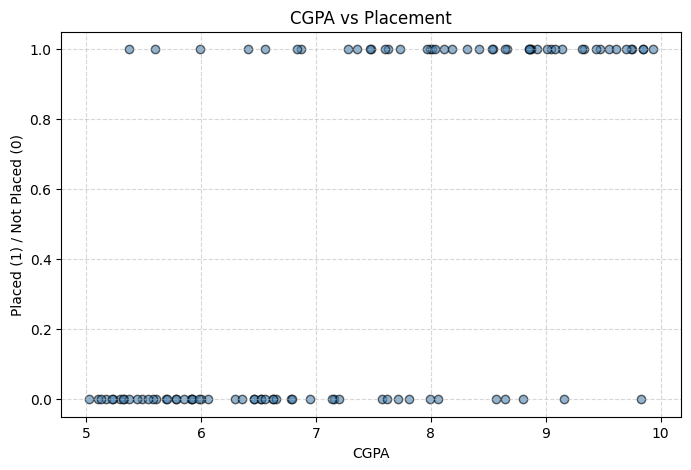

In [2]:
plt.figure(figsize=(8,5))
plt.scatter(cgpa, placed, color="steelblue", alpha=0.6, edgecolor="k")
plt.xlabel("CGPA")
plt.ylabel("Placed (1) / Not Placed (0)")
plt.title("CGPA vs Placement")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [3]:
from ml_from_scratch.base_model import BaseModel

class KNN(BaseModel):

    def __init__(self, k = 5):
        super().__init__()
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y.reshape(-1)
        self.is_fitted = True
        return self

    def euclidean_distance(self, point1, point2):
        return np.sqrt(np.sum((point1-point2)**2))

    def predict_single(self, x):
        distance = []
        for i in range(len(self.X_train)):
            dist = self.euclidean_distance(x, self.X_train[i])
            distance.append((dist, self.y_train[i]))

        distance.sort(key=lambda pair: pair[0])

        k_nearest_labels = []
        for i in range(self.k):
            k_nearest_labels.append(distance[i][1])

        label_count = {}
        for label in k_nearest_labels:
            if label in label_count:
                label_count[label] += 1
            else:
                label_count[label] = 1

        best_label = None
        best_count = 0
        for label, count in label_count.items():
            if count > best_count:
                best_count = count
                best_label = label

        return best_label

    def predict(self, X):
        self._check_is_fitted()
        predictions = []
        for x in X:
            predictions.append(self.predict_single(x))
        return np.array(predictions)

In [4]:
model = KNN(k=5)
model.fit(cgpa, placed)

predictions = model.predict(cgpa)
print(predictions[:10])

[0 1 1 1 0 0 0 1 1 1]


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

accuracy = accuracy_score(placed, predictions)
precision = precision_score(placed, predictions)
recall = recall_score(placed, predictions)
conf_matrix = confusion_matrix(placed, predictions)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.8
Precision: 0.8
Recall: 0.7659574468085106
Confusion Matrix:
 [[44  9]
 [11 36]]


In [9]:
from sklearn.neighbors import KNeighborsClassifier

sklearn_model = KNeighborsClassifier(n_neighbors=5)
sklearn_model.fit(cgpa, placed.ravel())
sklearn_predictions = sklearn_model.predict(cgpa)

sklearn_accuracy = accuracy_score(placed, sklearn_predictions)
print("Sklearn Accuracy:", sklearn_accuracy)

Sklearn Accuracy: 0.8


In [10]:
k_values = range(1, 22, 2)
accuracies = []

for k in k_values:
    model = KNN(k=k)
    model.fit(cgpa, placed)
    predictions = model.predict(cgpa)
    acc = accuracy_score(placed, predictions)
    accuracies.append(acc)

print(list(k_values))
print(accuracies)

[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
[1.0, 0.84, 0.8, 0.82, 0.78, 0.78, 0.81, 0.81, 0.82, 0.8, 0.8]


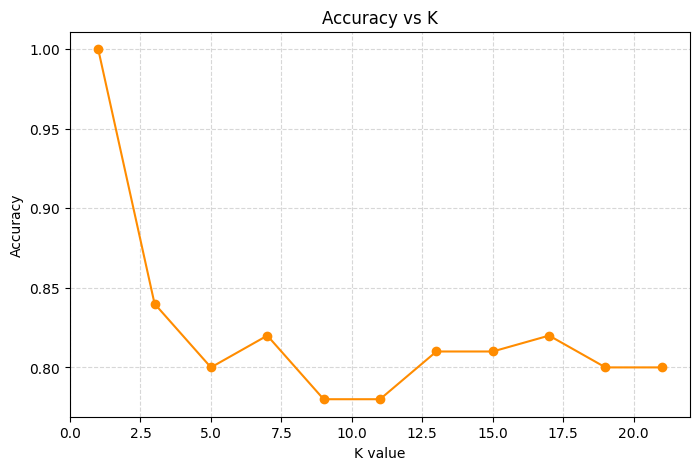

In [11]:
plt.figure(figsize=(8,5))
plt.plot(list(k_values), accuracies, marker="o", color="darkorange")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## What This Graph Tells Us

The accuracy at K=1 looks perfect (100%), but this is actually misleading.
Since I'm testing on the same data I trained on, K=1 basically means the
model's closest neighbor to any point is the point itself, so it always
gets it right. This isn't real learning, it's just memorizing.

Once K goes above 1, the accuracy drops and settles somewhere between
78-84%, which feels more like the model's real performance. Looking at
the graph, K=3 seems to give the best accuracy among the realistic
options, though a few other values like K=7 and K=17 are close behind.

## Conclusion

KNN works pretty differently from Linear and Logistic Regression. No
cost function, no gradients, no training loop - the model just stores
the data, and the actual work happens only when we ask it to predict
something.

One thing to keep in mind - distance is calculated only using the input
features, not the label. The label only comes into picture later, when
we count votes among the k nearest neighbors to get the final
prediction.

Picking the right K matters a lot here. A small K like K=1 can look like
it's giving perfect accuracy, but that's misleading if we're testing on
the same data we trained on - the closest point to any training sample
is just going to be itself. The elbow method helps with this, since it
lets us check a range of K values and pick one that gives more stable,
realistic accuracy instead of just guessing.

Results matched scikit-learn's implementation exactly, so the logic here
checks out.